<a href="https://colab.research.google.com/github/gargigautam72/Air-Quality-Analysis-based-on-Carbon-Monoxide-Forecasting-Using-Machine-Learning/blob/main/Air_Quality_Analysis_based_on_Carbon_Monoxide_Forecasting_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA)

In [76]:
import pandas as pd

df = pd.read_excel('/content/AirQualityUCI.xlsx')

# View the first few rows
print(df.head(10))

        Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)   C6H6(GT)  \
0 2004-03-10  18:00:00     2.6      1360.00       150  11.881723   
1 2004-03-10  19:00:00     2.0      1292.25       112   9.397165   
2 2004-03-10  20:00:00     2.2      1402.00        88   8.997817   
3 2004-03-10  21:00:00     2.2      1375.50        80   9.228796   
4 2004-03-10  22:00:00     1.6      1272.25        51   6.518224   
5 2004-03-10  23:00:00     1.2      1197.00        38   4.741012   
6 2004-03-11  00:00:00     1.2      1185.00        31   3.624399   
7 2004-03-11  01:00:00     1.0      1136.25        31   3.326677   
8 2004-03-11  02:00:00     0.9      1094.00        24   2.339416   
9 2004-03-11  03:00:00     0.6      1009.75        19   1.696658   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0        1045.50    166.0       1056.25    113.0       1692.00      1267.50   
1         954.75    103.0       1173.75     92.0       1558.75       972.25   
2         939.

In [77]:
# Missing values' count per column
print(df.isnull().sum())

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


In [78]:
# Counting the occurrences of -200 in each column
print((df == -200).sum())

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


In [79]:
# Display structural information and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           9357 non-null   datetime64[ns]
 1   Time           9357 non-null   object        
 2   CO(GT)         9357 non-null   float64       
 3   PT08.S1(CO)    9357 non-null   float64       
 4   NMHC(GT)       9357 non-null   int64         
 5   C6H6(GT)       9357 non-null   float64       
 6   PT08.S2(NMHC)  9357 non-null   float64       
 7   NOx(GT)        9357 non-null   float64       
 8   PT08.S3(NOx)   9357 non-null   float64       
 9   NO2(GT)        9357 non-null   float64       
 10  PT08.S4(NO2)   9357 non-null   float64       
 11  PT08.S5(O3)    9357 non-null   float64       
 12  T              9357 non-null   float64       
 13  RH             9357 non-null   float64       
 14  AH             9357 non-null   float64       
dtypes: datetime64[ns](1),

In [80]:
# Display statistical summaries
print(df.describe())

                                Date       CO(GT)  PT08.S1(CO)     NMHC(GT)  \
count                           9357  9357.000000  9357.000000  9357.000000   
mean   2004-09-21 04:30:05.193972480   -34.207524  1048.869652  -159.090093   
min              2004-03-10 00:00:00  -200.000000  -200.000000  -200.000000   
25%              2004-06-16 00:00:00     0.600000   921.000000  -200.000000   
50%              2004-09-21 00:00:00     1.500000  1052.500000  -200.000000   
75%              2004-12-28 00:00:00     2.600000  1221.250000  -200.000000   
max              2005-04-04 00:00:00    11.900000  2039.750000  1189.000000   
std                              NaN    77.657170   329.817015   139.789093   

          C6H6(GT)  PT08.S2(NMHC)      NOx(GT)  PT08.S3(NOx)      NO2(GT)  \
count  9357.000000    9357.000000  9357.000000   9357.000000  9357.000000   
mean      1.865576     894.475963   168.604200    794.872333    58.135898   
min    -200.000000    -200.000000  -200.000000   -200.000



---



# Data Preprocessing

In [81]:
import numpy as np

# Replacing invalid or missing values (-200) with NaN.
df = df.replace(-200, np.nan)

In [82]:
# Verifying the replacement

# Counting the occurrences of -200 in each column
print((df == -200).sum())

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


In [83]:
# Filling the missing values with the Column mean
df = df.fillna(df.mean(numeric_only=True))

In [84]:
# View the updated DataFrame
print(df.head(10))

        Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)   C6H6(GT)  \
0 2004-03-10  18:00:00     2.6      1360.00     150.0  11.881723   
1 2004-03-10  19:00:00     2.0      1292.25     112.0   9.397165   
2 2004-03-10  20:00:00     2.2      1402.00      88.0   8.997817   
3 2004-03-10  21:00:00     2.2      1375.50      80.0   9.228796   
4 2004-03-10  22:00:00     1.6      1272.25      51.0   6.518224   
5 2004-03-10  23:00:00     1.2      1197.00      38.0   4.741012   
6 2004-03-11  00:00:00     1.2      1185.00      31.0   3.624399   
7 2004-03-11  01:00:00     1.0      1136.25      31.0   3.326677   
8 2004-03-11  02:00:00     0.9      1094.00      24.0   2.339416   
9 2004-03-11  03:00:00     0.6      1009.75      19.0   1.696658   

   PT08.S2(NMHC)     NOx(GT)  PT08.S3(NOx)     NO2(GT)  PT08.S4(NO2)  \
0        1045.50  166.000000       1056.25  113.000000       1692.00   
1         954.75  103.000000       1173.75   92.000000       1558.75   
2         939.25  131.000000       

In [85]:
# Converting the Date and Time columns into a single datetime column with the YYYY-MM-DD HH:MM:SS format.
df['DateTime'] = pd.to_datetime(df['Date'].dt.strftime('%Y-%m-%d') + ' ' + df['Time'].astype(str), format='%Y-%m-%d %H:%M:%S')

In [86]:
# Check the result
print(df[['DateTime']].head(10))

             DateTime
0 2004-03-10 18:00:00
1 2004-03-10 19:00:00
2 2004-03-10 20:00:00
3 2004-03-10 21:00:00
4 2004-03-10 22:00:00
5 2004-03-10 23:00:00
6 2004-03-11 00:00:00
7 2004-03-11 01:00:00
8 2004-03-11 02:00:00
9 2004-03-11 03:00:00


In [87]:
# View the updated DataFrame with the new column 'DateTime' added
print(df.head(10))

        Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)   C6H6(GT)  \
0 2004-03-10  18:00:00     2.6      1360.00     150.0  11.881723   
1 2004-03-10  19:00:00     2.0      1292.25     112.0   9.397165   
2 2004-03-10  20:00:00     2.2      1402.00      88.0   8.997817   
3 2004-03-10  21:00:00     2.2      1375.50      80.0   9.228796   
4 2004-03-10  22:00:00     1.6      1272.25      51.0   6.518224   
5 2004-03-10  23:00:00     1.2      1197.00      38.0   4.741012   
6 2004-03-11  00:00:00     1.2      1185.00      31.0   3.624399   
7 2004-03-11  01:00:00     1.0      1136.25      31.0   3.326677   
8 2004-03-11  02:00:00     0.9      1094.00      24.0   2.339416   
9 2004-03-11  03:00:00     0.6      1009.75      19.0   1.696658   

   PT08.S2(NMHC)     NOx(GT)  PT08.S3(NOx)     NO2(GT)  PT08.S4(NO2)  \
0        1045.50  166.000000       1056.25  113.000000       1692.00   
1         954.75  103.000000       1173.75   92.000000       1558.75   
2         939.25  131.000000       

In [88]:
# Move DateTime to the third column (index 2)
datetime_col = df.pop('DateTime')
df.insert(2, 'DateTime', datetime_col)

# Display the updated DataFrame
print(df.head(10))

        Date      Time            DateTime  CO(GT)  PT08.S1(CO)  NMHC(GT)  \
0 2004-03-10  18:00:00 2004-03-10 18:00:00     2.6      1360.00     150.0   
1 2004-03-10  19:00:00 2004-03-10 19:00:00     2.0      1292.25     112.0   
2 2004-03-10  20:00:00 2004-03-10 20:00:00     2.2      1402.00      88.0   
3 2004-03-10  21:00:00 2004-03-10 21:00:00     2.2      1375.50      80.0   
4 2004-03-10  22:00:00 2004-03-10 22:00:00     1.6      1272.25      51.0   
5 2004-03-10  23:00:00 2004-03-10 23:00:00     1.2      1197.00      38.0   
6 2004-03-11  00:00:00 2004-03-11 00:00:00     1.2      1185.00      31.0   
7 2004-03-11  01:00:00 2004-03-11 01:00:00     1.0      1136.25      31.0   
8 2004-03-11  02:00:00 2004-03-11 02:00:00     0.9      1094.00      24.0   
9 2004-03-11  03:00:00 2004-03-11 03:00:00     0.6      1009.75      19.0   

    C6H6(GT)  PT08.S2(NMHC)     NOx(GT)  PT08.S3(NOx)     NO2(GT)  \
0  11.881723        1045.50  166.000000       1056.25  113.000000   
1   9.397165  



---



# Feature Engineering

In [89]:
# Retain important columns, such as pollutant levels and weather conditions.
df = df[['DateTime',
         'CO(GT)',
         'PT08.S1(CO)',
         'NMHC(GT)',
         'C6H6(GT)',
         'PT08.S2(NMHC)',
         'NOx(GT)',
         'PT08.S3(NOx)',
         'NO2(GT)',
         'PT08.S4(NO2)',
         'PT08.S5(O3)',
         'T',
         'RH',
         'AH']]

# Display the updated DataFrame
print(df.head(10))

             DateTime  CO(GT)  PT08.S1(CO)  NMHC(GT)   C6H6(GT)  \
0 2004-03-10 18:00:00     2.6      1360.00     150.0  11.881723   
1 2004-03-10 19:00:00     2.0      1292.25     112.0   9.397165   
2 2004-03-10 20:00:00     2.2      1402.00      88.0   8.997817   
3 2004-03-10 21:00:00     2.2      1375.50      80.0   9.228796   
4 2004-03-10 22:00:00     1.6      1272.25      51.0   6.518224   
5 2004-03-10 23:00:00     1.2      1197.00      38.0   4.741012   
6 2004-03-11 00:00:00     1.2      1185.00      31.0   3.624399   
7 2004-03-11 01:00:00     1.0      1136.25      31.0   3.326677   
8 2004-03-11 02:00:00     0.9      1094.00      24.0   2.339416   
9 2004-03-11 03:00:00     0.6      1009.75      19.0   1.696658   

   PT08.S2(NMHC)     NOx(GT)  PT08.S3(NOx)     NO2(GT)  PT08.S4(NO2)  \
0        1045.50  166.000000       1056.25  113.000000       1692.00   
1         954.75  103.000000       1173.75   92.000000       1558.75   
2         939.25  131.000000       1140.00  11

In [90]:
# Scaling the data using StandardScaler or MinMaxScaler

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Initialize the scalers
std_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

# Selecting only columns with numerical values
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# StandardScaler makes mean=0 and std=1
df_std = std_scaler.fit_transform(df[numerical_columns])

# MinMaxScaler makes the range [0, 1]
df_minmax = minmax_scaler.fit_transform(df[numerical_columns])

# Converting NumPy arrays back to Pandas DataFrames
df_std = pd.DataFrame(df_std, columns=numerical_columns)
df_minmax = pd.DataFrame(df_minmax, columns=numerical_columns)

# Inserting the DateTime column in the two new scaled DataFrames
df_std.insert(0, 'DateTime', df['DateTime'])
df_minmax.insert(0, 'DateTime', df['DateTime'])

# Displaying the original and the two new DataFrames
print("Original DataFrame is: \n\n", df.head(10))
print("\n\n\nStandardScalar DataFrame is: \n\n", df_std.head(10))
print("\n\n\nMinMaxScaler DataFrame is: \n\n", df_minmax.head(10))

Original DataFrame is: 

              DateTime  CO(GT)  PT08.S1(CO)  NMHC(GT)   C6H6(GT)  \
0 2004-03-10 18:00:00     2.6      1360.00     150.0  11.881723   
1 2004-03-10 19:00:00     2.0      1292.25     112.0   9.397165   
2 2004-03-10 20:00:00     2.2      1402.00      88.0   8.997817   
3 2004-03-10 21:00:00     2.2      1375.50      80.0   9.228796   
4 2004-03-10 22:00:00     1.6      1272.25      51.0   6.518224   
5 2004-03-10 23:00:00     1.2      1197.00      38.0   4.741012   
6 2004-03-11 00:00:00     1.2      1185.00      31.0   3.624399   
7 2004-03-11 01:00:00     1.0      1136.25      31.0   3.326677   
8 2004-03-11 02:00:00     0.9      1094.00      24.0   2.339416   
9 2004-03-11 03:00:00     0.6      1009.75      19.0   1.696658   

   PT08.S2(NMHC)     NOx(GT)  PT08.S3(NOx)     NO2(GT)  PT08.S4(NO2)  \
0        1045.50  166.000000       1056.25  113.000000       1692.00   
1         954.75  103.000000       1173.75   92.000000       1558.75   
2         939.25  13

In [91]:
# Verifying the scaling done to the DataFrame df using StandardScaler
#     or MinMaxScaler to get df_std and df_minmax respectively

# Original DataFrame
print("For the Original DataFrame:")
print("-------------------------------")
print("\nMean:\n\n", df.mean(numeric_only=True))
print("-------------------------------")
print("\nStandard Deviation:\n\n", df.std(numeric_only=True))
print("-------------------------------")
print("\nMinimum Value:\n\n", df.min(numeric_only=True))
print("-------------------------------")
print("\nMaximum Value:\n\n", df.max(numeric_only=True))

print("\n______________________________________")
print("______________________________________")

# StandardScaler verification
print("\n\nFor StandardScalar DataFrame:")
print("---------------------------------")
print("\nMean:\n\n", df_std.mean(numeric_only=True))
print("---------------------------------")
print("\nStandard Deviation:\n\n", df_std.std(numeric_only=True))

print("\n______________________________________")
print("______________________________________")

# MinMaxScaler verification
print("\n\nFor MinMaxScaler DataFrame:")
print("-------------------------------")
print("\nMinimum Value:\n\n", df_minmax.min(numeric_only=True))
print("-------------------------------")
print("\nMaximum Value:\n\n", df_minmax.max(numeric_only=True))

For the Original DataFrame:
-------------------------------

Mean:

 CO(GT)              2.152750
PT08.S1(CO)      1099.707856
NMHC(GT)          218.811816
C6H6(GT)           10.082993
PT08.S2(NMHC)     939.029205
NOx(GT)           246.881252
PT08.S3(NOx)      835.370973
NO2(GT)           113.075515
PT08.S4(NO2)     1456.143486
PT08.S5(O3)      1022.780725
T                  18.316054
RH                 49.232360
AH                  1.025530
dtype: float64
-------------------------------

Standard Deviation:

 CO(GT)             1.316068
PT08.S1(CO)      212.796116
NMHC(GT)          63.870229
C6H6(GT)           7.302474
PT08.S2(NMHC)    261.557856
NOx(GT)          193.419417
PT08.S3(NOx)     251.741784
NO2(GT)           43.911095
PT08.S4(NO2)     339.365351
PT08.S5(O3)      390.609000
T                  8.658396
RH                16.974308
AH                 0.395836
dtype: float64
-------------------------------

Minimum Value:

 CO(GT)             0.100000
PT08.S1(CO)      647.250000


### Conclusion of the verfication:

For all the numerical variables in the DataFrame:
*   In StandardScaler DataFrame df_std : <br> &nbsp; &nbsp; Mean ≈ 0 and Standard deviation ≈ 1
*   In MinMaxScaler DataFrame df_minmax : <br> &nbsp; &nbsp; Min = 0 and Max = 1

Hence the scaling done above via StandardScaler and MinMaxScaler is verified.





---



# Model Development

In [92]:
# Spliting the data into training and testing sets using train_test_split.

from sklearn.model_selection import train_test_split

# Split the original dataset
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=['CO(GT)']),  # feature variables
    df['CO(GT)'],                 # target variable
    test_size=0.3,
    shuffle=False)

# Display the shapes (i.e. the dimensions of the training and testing datasets)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (6549, 13)
X_test : (2808, 13)
y_train: (6549,)
y_test : (2808,)


Conclusion:

*   The original DataFrame (df) was successfully divided into training and testing sets in a 70:30 ratio.
*   The Feature Variables (i.e. the predictor variables) were stored in the feature DataFrame (X), while the target variable (CO(GT)) was stored in the target Series (y).
*   This split has prepared the data for model training and performance evaluation, while preserving the chronological order of the observations.

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.




The new DataFrame prepared to do time-series forecasting using Prophet is:

                   ds    y
0 2004-03-10 18:00:00  2.6
1 2004-03-10 19:00:00  2.0
2 2004-03-10 20:00:00  2.2
3 2004-03-10 21:00:00  2.2
4 2004-03-10 22:00:00  1.6
5 2004-03-10 23:00:00  1.2
6 2004-03-11 00:00:00  1.2
7 2004-03-11 01:00:00  1.0
8 2004-03-11 02:00:00  0.9
9 2004-03-11 03:00:00  0.6


The predictions are:

                      ds      yhat  yhat_lower  yhat_upper
9395 2005-04-06 05:00:00  0.897774   -0.477943    2.306517
9396 2005-04-06 06:00:00  1.276100   -0.068847    2.604182
9397 2005-04-06 07:00:00  1.856933    0.479411    3.376100
9398 2005-04-06 08:00:00  2.346292    1.112783    3.696473
9399 2005-04-06 09:00:00  2.540118    1.147325    3.881637
9400 2005-04-06 10:00:00  2.446877    1.166248    3.867532
9401 2005-04-06 11:00:00  2.225415    0.985177    3.663600
9402 2005-04-06 12:00:00  2.028344    0.784986    3.451383
9403 2005-04-06 13:00:00  1.910884    0.598565    3.316790
9404 2005-0

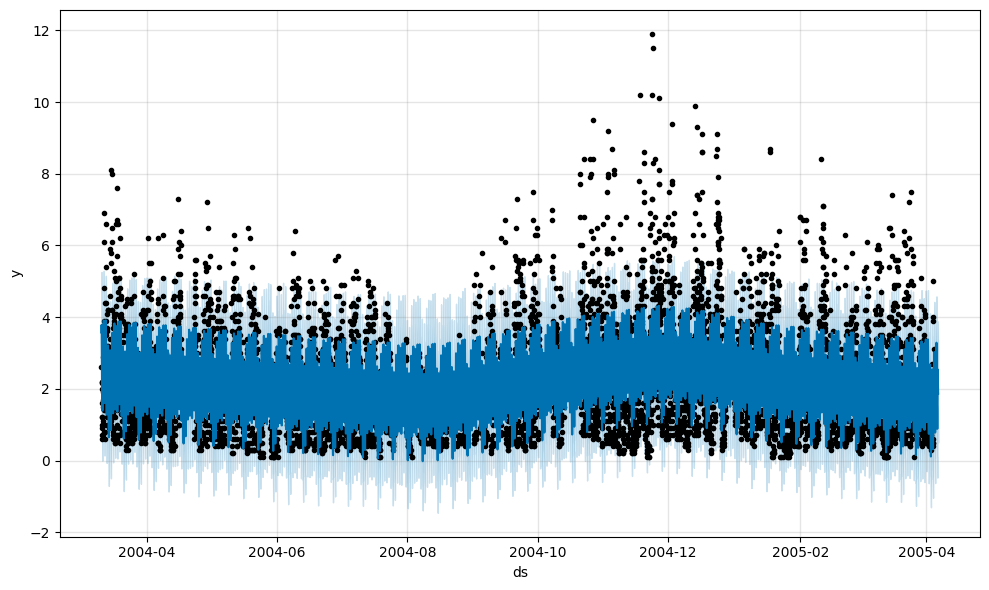



Forecast Components:
The graph below illustrates the trend and the seasonal patterns (weekly and daily) learned by the Prophet model.



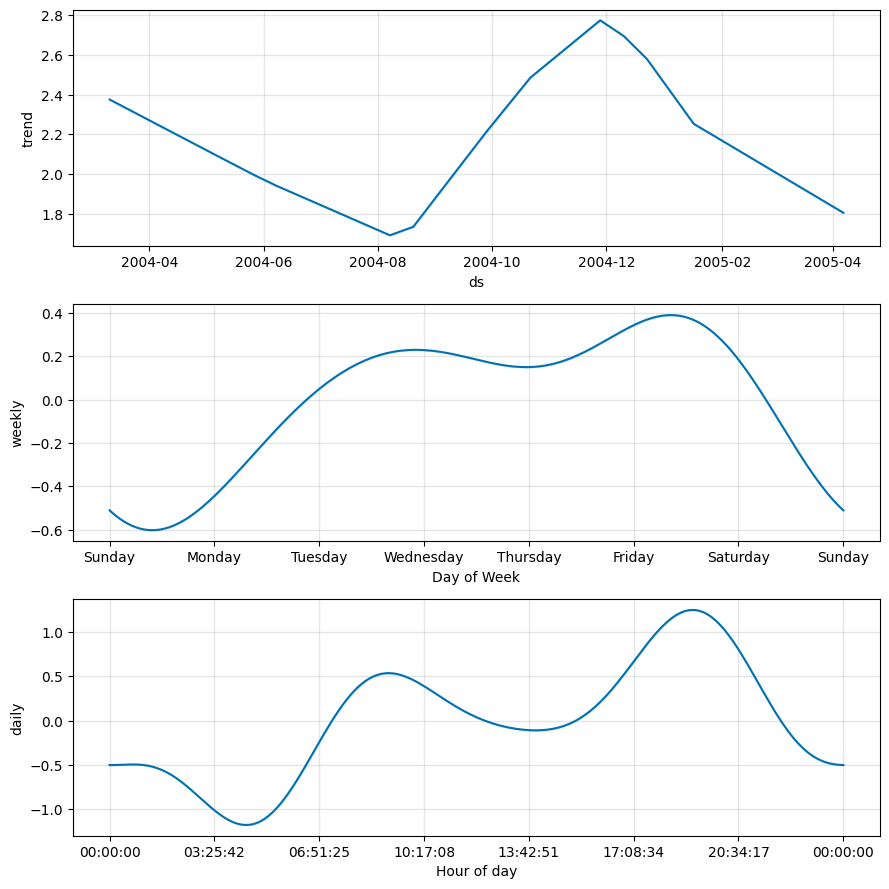

In [93]:
# Building a time-series forecasting model using prophet:
#   o Renaming the datetime column to ds and the target column to y.
#   o Training the model on ds and y.
#   o Predicting future air quality based on CO Concentrations.


!pip install -q prophet
# "-q" (stands for quiet) ensures that only important messages are displayed.

from prophet import Prophet

# Preparing the DataFrame for Prophet and renaming the columns
prophet_df = df[['DateTime', 'CO(GT)']].copy()
prophet_df.rename(columns={'DateTime': 'ds',
                           'CO(GT)': 'y'},
                  inplace=True)

print("\n\nThe new DataFrame prepared to do time-series forecasting using Prophet is:\n")
print(prophet_df.head(10))

# Initializing the Prophet model
model = Prophet()     # This creates an untrained model that will learn (i.e. train) from the data that will be provided to it.

# Training the model
model.fit(prophet_df)     # The model studies the historical data on air quality from the DataFrame prophet_df,
                          # and stores the learned parameters in the 'model' object.

# Creating future timestamps, where we want to make predictions, say next 48 hours.
future = model.make_future_dataframe(periods=48, freq='h')

# Predict future values
forecast = model.predict(future)    # estimates future CO(GT) values for the generated timestamps, using the trained model.

# Display the predictions
print("\n\nThe predictions are:\n")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))
print("\n\n")

import matplotlib.pyplot as plt

# Plot the forecast
print("\n\nForecast:")
print("The graph below shows the historical CO(GT) values along with the forecasted values for the next 48 hours.\n")
model.plot(forecast)
plt.show()

# Plot the forecast components, i.e. the trend and seasonality
print("\n\nForecast Components:")
print("The graph below illustrates the trend and the seasonal patterns (weekly and daily) learned by the Prophet model.\n")
model.plot_components(forecast)
plt.show()

## Interpretation of the graphs:
  ### Forecast Plot:
*   It visualizes both the historical and the predicted CO(GT) values over time, illustrating the expected CO(GT) Concentration levels for the forecast period.
    *   Black dots represent the actual historical CO(GT) observations.
    *   Blue line represent Prophet's fitted values for the historical period and its forecast for the future timestamps.
    *   Light blue shaded region represents the uncertainty (confidence interval) of the predictions.
        *   The wider the band, the greater the uncertainty.
*   The forecast shows a moderate increase in CO(GT) during the middle of the observed period, around October–December 2004, followed by a gradual decline.
*   The uncertainty interval remains relatively stable, indicating that the model's confidence is reasonably consistent throughout the forecast period.
*   Most observations are concentrated around the predicted values, while some extreme values lie outside the prediction band. Overall, the model adequately represents the general trend of the air quality based on CO(GT) Concentration.    

  ### Trend Plot
*   It represents the long-term trend after removing the seasonal effects.
*   The CO(GT) concentrations initially decreased, indicating an improvement in air quality.
*   Then, it increased significantly during late 2004, indicating a decline in the air quality.
*   Towards the end of the study period (i.e. in early 2005), CO concentration declined again, suggesting an improvement in the air quality.
*   This trend likely reflects seasonal and environmental influences affecting air quality based on CO(GT) Concentration.

  ### Weekly Seasonality Plot
*   This graph shows that pollution gradually increases from Monday to Friday, when it starts to reduce until Sunday.
*   It indicates that CO(GT) concentrations are generally lower on weekends and higher during weekdays, with the highest values around Friday and lowest on Sunday.
*   This pattern suggests that human activities contribute more to CO emissions on weekdays than weekends.

  ### Daily Seasonality Plot
*   This graph represents the average variation in CO(GT) during a 24-hour period.
*   The daily seasonal component shows a clear diurnal pattern.
*   CO(GT) concentrations are lowest during the early morning, increase during the morning, reach their maximum during the evening, and then decline overnight.
*   This pattern is consistent with daily traffic and human activity cycles.
*   The evening peak is stronger than the morning peak.



## Conclusions:
*   A time-series forecasting model was developed using the prophet library.
*   For this, a new DataFrame prophet_df was created by selecting the DateTime and CO(GT) columns from the original DataFrame df.
    *   These columns were then renamed to ds and y respectively, to meet Prophet's input requirements.
*   The model was trained on the historical air quality data, where it learned the underlying long-term trend and seasonal patterns.
    *   Using these learned patterns, the model generated forecasts for the next 48 hours, providing predicted CO(GT) values (yhat) along with lower and upper confidence intervals (yhat_lower and yhat_upper).
*   The trend reveals gradual changes in pollution levels over the year, while the weekly and daily components capture recurring patterns associated with human activities.
*   Using these learned patterns, the model generated forecasts of future CO(GT) concentrations together with confidence intervals, demonstrating its effectiveness for time-series forecasting of CO(GT) Concentration.
*   The Prophet model successfully identified three important characteristics of the CO(GT) Concentration data: a long-term trend, weekly seasonal variation, and daily seasonal variation.  
*   The forecast and its components help visualize the expected future CO(GT) Concentration trends and the uncertainty (confidence intervals) associated with the predictions.
    *  These visualizations help interpret the model's predictions and understand the temporal behavior of CO(GT) Concentration.


# Model Evaluation

In [94]:
# Using the evaluation metrics:
#   o Mean Absolute Error (MAE),
#   o Root Mean Square Error (RMSE),
#   o R-squared (R2)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Extracting the actual values
y_true = prophet_df['y']

# Extracting the predicted values corresponding to the historical observations
y_pred = forecast['yhat'][:len(prophet_df)]

# Calculating the evaluation metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# Displaying the results
print("Model Evaluation Metrics:\n")
print("Mean Absolute Error (MAE):", round(mae, 4))
print("Root Mean Square Error (RMSE):", round(rmse, 4))
print("R-squared (R²):", round(r2, 4))

Model Evaluation Metrics:

Mean Absolute Error (MAE): 0.7938
Root Mean Square Error (RMSE): 1.0551
R-squared (R²): 0.3571


## Interpretations for each of the evaluation metrics:

*   MAE
    *   MAE measures the average magnitude of prediction errors without considering their direction.
    *   It gives equal weight to all prediction errors regardless of their magnitude.
    *   A lower MAE indicates that the predicted values are closer to the actual observations, hence demonstrating better forecasting accuracy.
    *   MAE value of 0.7938 indicates that, on an average, the Prophet model's predicted CO(GT) values differ from the actual values by approximately 0.79 units.
    *   Hence, the obtained MAE suggests that the model provides reasonably accurate predictions with relatively small average prediction error.

*   RMSE
    *   RMSE measures the standard deviation of prediction errors, while penalizing large errors more heavily than MAE (as the error values are squared before averaging).
    *   A lower RMSE indicates better predictive accuracy.
    *   The RMSE value of 1.0551 is only marginally higher than the MAE value of 0.7938, hence suggesting that the model does not produce many extremely large prediction errors.
    *   This indicates a relatively consistent forecasting performance with limited extreme deviations between the predicted and observed CO(GT) values.

*   R²
    *   The R² score measures how well the model explains the variability in the observed values, thereby measuring its goodness of fit.
    *   Values closer to 1 indicate a better fit to the historical data.
    *   The obtained R² value of 0.3571 indicates that the Prophet model explains approximately 35.71% of the variation in the observed CO(GT) values.
    *   This suggests that the model's overall fit to the observed CO(GT) values is moderate.
    *   The unexplained variation may be due to factors such as weather conditions, sudden environmental changes, traffic fluctuations, or other variables that were not explicitly included here in the above forecasting model.

## Conclusions:

*   The Prophet model was evaluated using MAE, RMSE, and R² to assess its forecasting performance.
*   Together, these evaluation metrics provide a comprehensive assessment of the forecasting model's prediction accuracy, robustness to large errors, and predictive capability to forecast air quality levels based on CO(GT) concentrations.
*   The model achieved a MAE of 0.7938, RMSE of 1.0551, and R² of 0.3571, indicating reasonable accuracy and consistent forecasts with moderate predictive performance.


##  Model Refinement Strategy:

*   While the Prophet model successfully captures the general trend and seasonality of air quality based on CO(GT) concentrations, a considerable portion of the variability remains unexplained.
*   For this, let us incorporate additional environmental factors in the following work.





-----




# Finding out which variable should be incorporated in the above model to get more precise predictions for CO(GT) values:

## Pearson Linear Correlation Analysis for CO(GT)

Linear Correlation Analysis for CO(GT):

CO(GT)           1.000000
C6H6(GT)         0.812392
PT08.S2(NMHC)    0.795586
PT08.S1(CO)      0.773394
NOx(GT)          0.762297
PT08.S5(O3)      0.759027
NO2(GT)          0.646528
PT08.S4(NO2)     0.558225
NMHC(GT)         0.289975
AH               0.043273
RH               0.043204
T                0.020260
PT08.S3(NOx)    -0.613870
Name: CO(GT), dtype: float64 



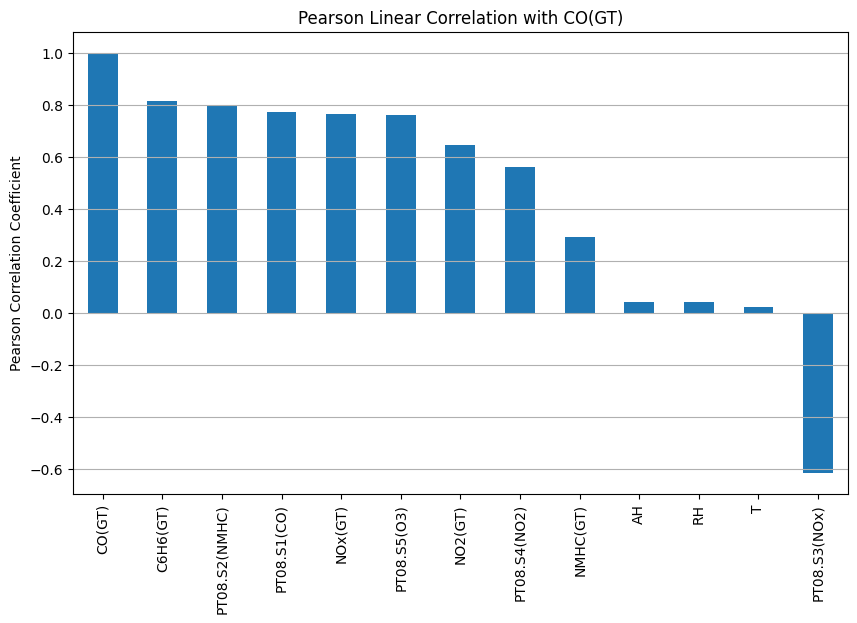

In [95]:
# Calculate the Pearson correlation coefficients
correlation = df.corr(method='pearson', numeric_only=True)

# Display the correlation of all variables with CO(GT)
print("Linear Correlation Analysis for CO(GT):\n")
print(correlation['CO(GT)'].sort_values(ascending=False), "\n")

# Visualizing the linear correlation coefficients
correlation['CO(GT)'].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10,6))

plt.title("Pearson Linear Correlation with CO(GT)")
plt.ylabel("Pearson Correlation Coefficient")
plt.grid(axis='y')

plt.show()

### Interpretations & Conclusions:

*   CO(GT) has a perfect positive correlation with itself.
*   C6H6(GT) and PT08.S2(NMHC) exhibit the strongest positive linear correlation with CO(GT) (= 0.8124 and 0.7956 respectively).
* This indicates that their concentrations are strongly and directly related to CO(GT).
*  Hence, C6H6(GT) and PT08.S2(NMHC) are the two most influential predictor of CO(GT) among the variables considered.

## **Feature Importance analysis** via **Random Forest Regression** (Supervised Machine Learning)

In [71]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop(columns=['CO(GT)', 'DateTime'])
y = df['CO(GT)']

model = RandomForestRegressor(random_state=42)

model.fit(X,y)

RandomForestRegressor(random_state=42)

In [72]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns).sort_values(ascending=False)

print(importance)

C6H6(GT)         0.357450
PT08.S2(NMHC)    0.283710
NOx(GT)          0.183229
PT08.S1(CO)      0.049748
NO2(GT)          0.027933
T                0.021076
PT08.S5(O3)      0.017489
PT08.S3(NOx)     0.016090
PT08.S4(NO2)     0.013951
RH               0.013045
AH               0.011850
NMHC(GT)         0.004429
dtype: float64


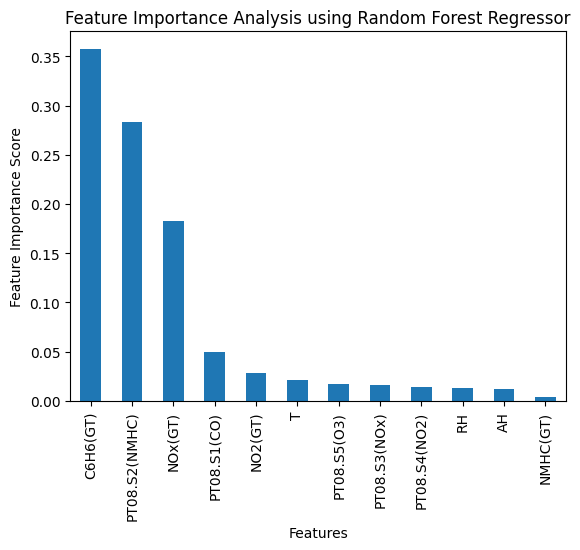

In [73]:
importance.plot(kind='bar')

plt.title("Feature Importance Analysis using Random Forest Regressor")
plt.xlabel("Features")
plt.ylabel("Feature Importance Score")

plt.show();

### Interpretations & Conclusions of Random Forest Regression:

*   C6H6(GT) has the highest feature importance (≈0.36), indicating that it is the most influential predictor of CO(GT).
*   It is followed by PT08.S2(NMHC) and NOx(GT), with feature importance ≈0.28 and ≈0.18 respectively, demonstrating a substantial contribution to the prediction of CO(GT) values.



## Correlation heatmap

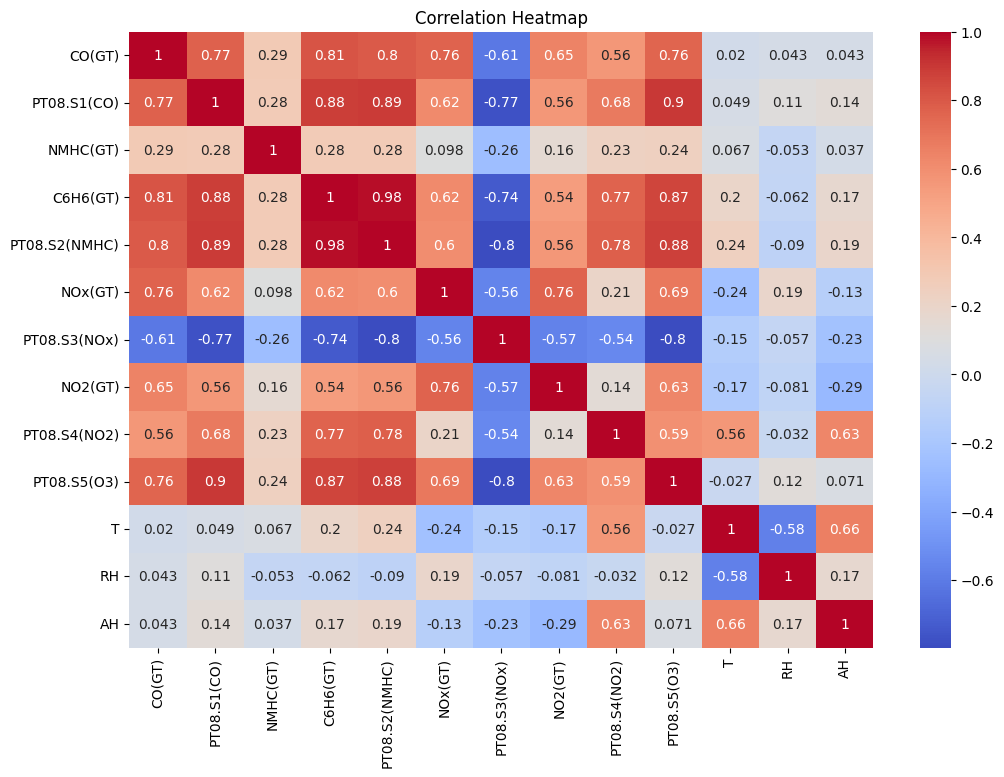

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

### Interpretations & Conclusions of Correlation heatmap:

*   CO(GT) exhibits a strongest positive correlation with:
          
        C6H6(GT) (0.81)
           and
        PT08.S2(NMHC) (0.80)

*   This indicates that these variables tend to increase or decrease together with the CO(GT) concentration.
*   Also, C6H6(GT) and PT08.S2(NMHC) have an extremely high correlation (0.98) with each other.

## Final Conclusion:

*   The correlation analysis, feature importance analysis (Random Forest) and the correlation heatmap consistently identify C6H6(GT) and PT08.S2(NMHC) as the two most influential predictors of CO(GT).
*   Further, the Correlation heatmap also reveals multicollinearity between C6H6(GT) and PT08.S2(NMHC), which have a very strong positive correlation of 0.98.
    * This indicates that they carry almost identical information, and hence are likely to provide redundant information to our predictive model.
*   Therefore, C6H6(GT) can be considered one of the most informative variables for forecasting CO(GT).
*   Hence, we choose C6H6(GT) as the variable to be incorporated in our model developed above, to get more precise predictions for CO(GT) values.



---



# Developing an Improved Prophet Model using C6H6(GT) as an External Regressor, and evaluating it using MAE, RMSE and R²:


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.



The DataFrame to be used for the improved Prophet model is:

                   ds    y       C6H6
0 2004-03-10 18:00:00  2.6  11.881723
1 2004-03-10 19:00:00  2.0   9.397165
2 2004-03-10 20:00:00  2.2   8.997817
3 2004-03-10 21:00:00  2.2   9.228796
4 2004-03-10 22:00:00  1.6   6.518224
5 2004-03-10 23:00:00  1.2   4.741012
6 2004-03-11 00:00:00  1.2   3.624399
7 2004-03-11 01:00:00  1.0   3.326677
8 2004-03-11 02:00:00  0.9   2.339416
9 2004-03-11 03:00:00  0.6   1.696658 



Predictions are:

                      ds      yhat  yhat_lower  yhat_upper
9395 2005-04-06 05:00:00  2.137586    1.249206    3.024793
9396 2005-04-06 06:00:00  1.998067    1.083980    2.957549
9397 2005-04-06 07:00:00  1.959203    0.997035    2.828688
9398 2005-04-06 08:00:00  2.038736    1.195776    2.980868
9399 2005-04-06 09:00:00  2.170410    1.279660    3.063231
9400 2005-04-06 10:00:00  2.261746    1.379325    3.190389
9401 2005-04-06 11:00:00  2.264580    1.407412    3.198728
9402 2005-04-06 12:00:00  

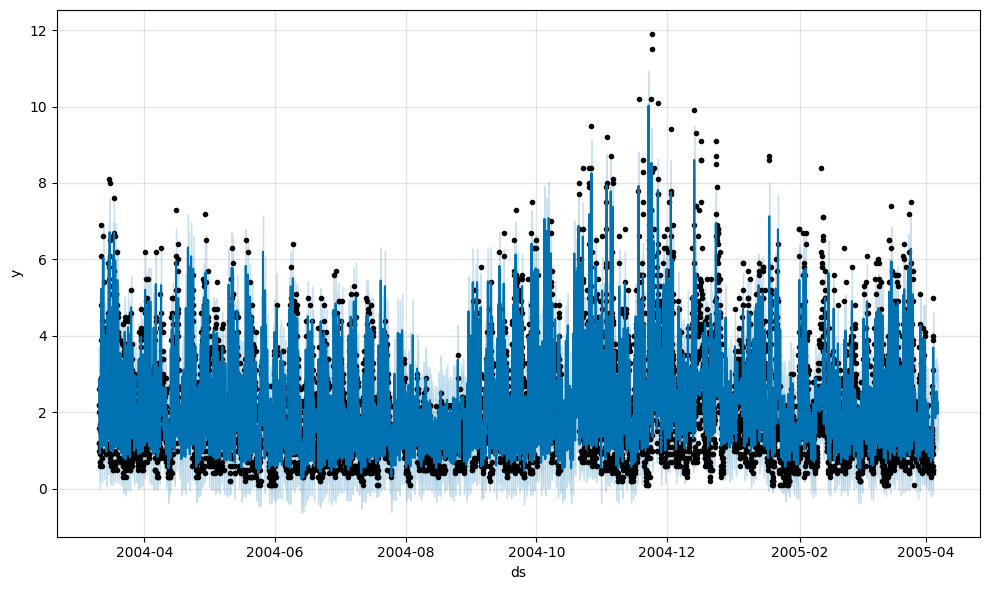



Forecast Components:


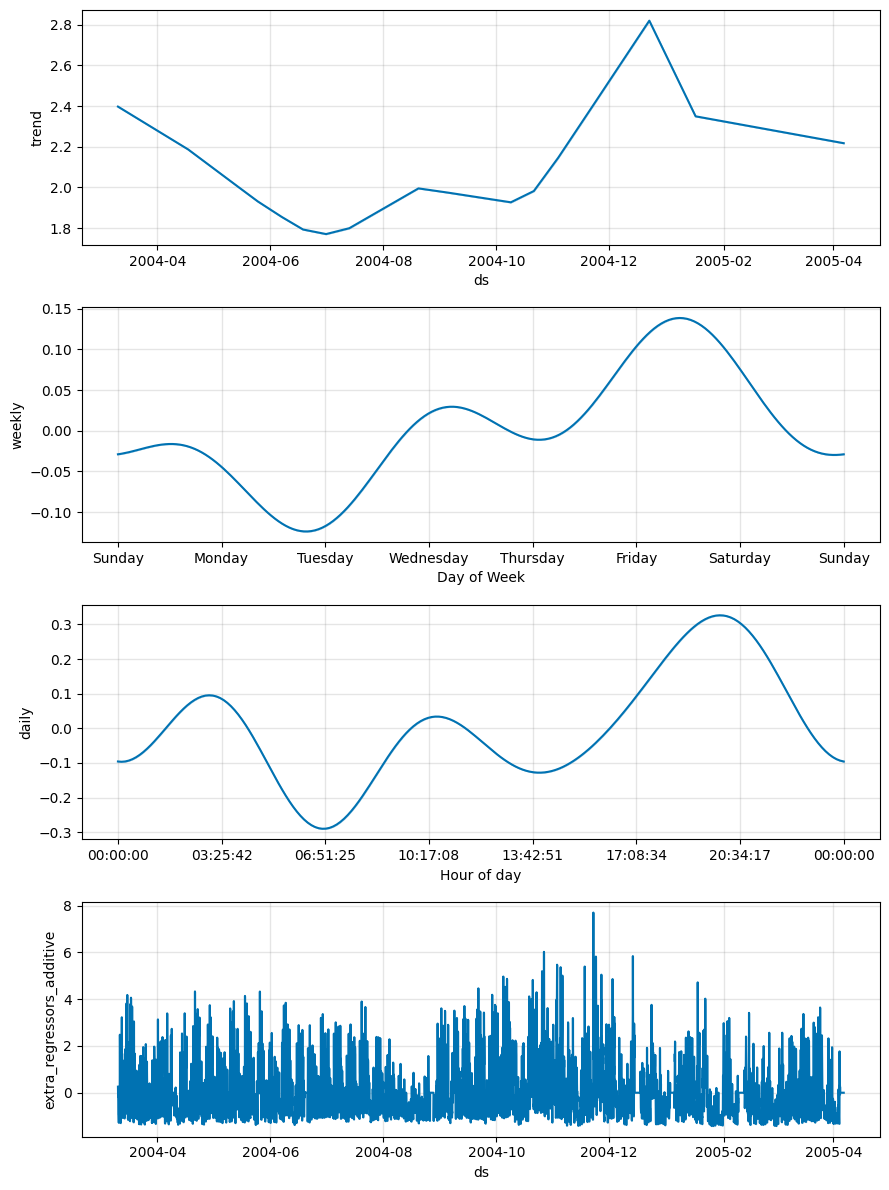



Improved Model Evaluation Metrics are:

Mean Absolute Error (MAE): 0.47
Root Mean Square Error (RMSE): 0.6986
R-squared (R²): 0.7182


In [75]:
# ==============================================================
# Improved Prophet Model using C6H6(GT) as an External Regressor
# ==============================================================

# Preparing the new DataFrame
prophet_df2 = df[['DateTime', 'CO(GT)', 'C6H6(GT)']].copy()

# Renaming columns according to Prophet requirements
prophet_df2.rename(columns={
    'DateTime': 'ds',
    'CO(GT)': 'y',
    'C6H6(GT)': 'C6H6'
  }, inplace=True)

print("\nThe DataFrame to be used for the improved Prophet model is:\n")
print(prophet_df2.head(10), "\n")

# Initializing the Prophet model
model2 = Prophet()

# Adding C6H6 as an external regressor
#   (so that Prophet knows that it should also use the C6H6 column for
#   prediction along with DateTime)
model2.add_regressor('C6H6')

# Train the model
model2.fit(prophet_df2)

# Create future timestamps
future2 = model2.make_future_dataframe(periods=48, freq='h')

# ------------------------------------------------------------
# Providing values of the external regressor C6H6
# ------------------------------------------------------------

# Adding a column of Historical C6H6 values to future2
future2['C6H6'] = prophet_df2['C6H6']

# Adding Future C6H6 values
# (assuming constant= average of all the historical values for C6H6)
#   (because C6H6 values corresponding to the newly created 48 future timestamps
#   don't exist in the original dataset and hence become NaN (missing).)
future2.loc[len(prophet_df2):, 'C6H6'] = prophet_df2['C6H6'].mean()

# ------------------------------------------------------------

# Predicting future CO(GT)
forecast2 = model2.predict(future2)
print("\n\nPredictions are:\n")
print(forecast2[['ds','yhat','yhat_lower','yhat_upper']].tail(10))

# Forecast Plot
print("\n\nForecast using Prophet + C6H6(GT):")
model2.plot(forecast2)
plt.show()

# Forecast Components Plot
print("\n\nForecast Components:")
model2.plot_components(forecast2)
plt.show()

# ------------------------------------------------------------
# Model Evaluation
# ------------------------------------------------------------

# Actual values
y_true = prophet_df2['y']

# Predicted values (corresponding to historical observations)
y_pred = forecast2['yhat'][:len(prophet_df2)]

# Evaluation metrics
mae2 = mean_absolute_error(y_true, y_pred)
rmse2 = np.sqrt(mean_squared_error(y_true, y_pred))
r2_2 = r2_score(y_true, y_pred)

print("\n\nImproved Model Evaluation Metrics are:\n")

print("Mean Absolute Error (MAE):", round(mae2,4))
print("Root Mean Square Error (RMSE):", round(rmse2,4))
print("R-squared (R²):", round(r2_2,4))

# Comparison between the new and the old models developed:

*   Forecast Plot (Observed vs Predicted CO(GT))
    *   Compared to the previous model 'model', the predicted values follow the observed CO(GT) concentrations more closely.
    *   The new model 'model2' captures the overall fluctuations (i.e. variations in the CO(GT) concentration) and seasonal behaviour (weekly and daily seasonality) more accurately after incorporating C6H6(GT) as an external regressor.
    *   Moreover, the improved Prophet model captures several high CO(GT) peaks more accurately.
*  Trend
    *   Compared to the previous model, the overall trend pattern remains almost unchanged.
    *   This is because adding a predictor variable C6H6(GT) improves the prediction accuracy rather than altering the underlying long-term trend learned from the data.
*   Weekly Seasonality
    *   Compared with the previous model, the weekly seasonal pattern becomes slightly smoother
    * It is so because some variability is now explained by the external regressor rather than being absorbed into the seasonal component.
*   Daily Seasonality
    *   The daily pattern remains similar to that of the previous model.
    *   However, the daily seasonal component becomes less dominant in the new model, because part of the variability (fluctuations) is now explained by C6H6(GT).
*   Extra Regressor Component (C6H6)
    *   The graph represents the contribution of the external regressor C6H6(GT) towards predicting CO(GT).
    *   The graph shows considerable variation over time, indicating that changes in benzene concentration have a substantial influence on the predicted CO(GT) values.
    *   Periods where the contribution is higher correspond to periods where C6H6(GT) provides stronger predictive information.
    *   This validates the earlier findings obtained from the Pearson Linear Correlation Analysis, Feature Importance Analysis (Random Forest) and Correlation heatmap, all of which identified C6H6(GT) as the most influential predictor of CO(GT) values.
*   MAE
    *   The average prediction error has decreased considerably from 0.7938 to 0.47, indicating a substantial improvement in forecasting accuracy.
*   RMSE
    *   RMSE has decreased significantly from 1.0551 to 0.6986, indicating better predictive accuracy compared to the initial model.
    *   Moreover, RMSE is now even closer to MAE, which ensures more consistent forecasts.
    *   This also implies that the improved model produces fewer large prediction errors.
*   R²
    * Compared with the previous model (R² = 0.3571), the explained variation has nearly doubled to 71.82%
    *   This demonstrates that incorporating C6H6(GT) enables the model to explain a much larger proportion of the variability in CO(GT).

# Conclusion:

*   The incorporation of C6H6(GT) as an external regressor substantially improved the fit of the Prophet forecasting model to the historical data.
*   Lowered MAE and RMSE values and increased R² score also indicated the same.
*   This demonstrates that C6H6(GT) contains valuable predictive information for estimating the CO(GT) concentrations.






---



# Project Summary:

*   In this project, a machine learning-based framework was developed for forecasting carbon monoxide (CO) concentrations, using CO levels as an indicator of air quality.
*   Successfully performed EDA, data preprocessing, and feature engineering including feature scaling using StandardScaler and MinMaxScaler on CO concentration values.
*   Through Prophet-based time-series forecasting, the initial model successfully captured temporal patterns in CO levels.
*   Further enhancement using C6H6(GT) as an external regressor significantly improved forecasting accuracy and explained variation, demonstrating a strong predictive relationship of C6H6 with CO levels.
*   The models developed were evaluated using the MAE, RMSE, and R² metrics, demonstrating excellent performance of the models.
*   Overall, the project highlights how integrating statistical analysis with machine learning can improve the analysis of historical air quality data. This further contributes to reliable forecasts, thereby supporting more effective air quality monitoring and data-driven decision-making.




---

